# 03 — Video Pipeline and Multimodal Evidence (Day 2.5)

This notebook is the **authoritative evidence** that the genuine Video Package/Pipeline and the
claim-level multimodal evidence candidate layer exist and were actually run — Notebook 02 covers
the Text Package and descriptive creator/engagement analysis only and is **not** relied on here.

Per `CLAUDE.md` §9 / `docs/project_charter.md`: a YouTube URL, oEmbed thumbnail, title,
description, or engagement statistic is a **video lead**, never a processed video asset.
Everything below distinguishes the two explicitly, and reports shortfalls honestly rather than
fabricating coverage.

Pipeline entry point: `python scripts/run_day2_5_modality_alignment.py`
Authoritative status: `outputs/tables/assignment_modality_audit.csv`
Full narrative: `docs/assignment_alignment_audit.md`

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
from IPython.display import Image as IPyImage, display as ipy_display

pd.set_option("display.max_colwidth", 100)
RANDOM_SEED = 42

PROCESSED = PROJECT_ROOT / "data" / "processed"
INTERIM_DAY2_5 = PROJECT_ROOT / "data" / "interim" / "day2_5"
TABLES = PROJECT_ROOT / "outputs" / "tables"

image_assets = pd.read_csv(INTERIM_DAY2_5 / "image_assets.csv")
video_assets = pd.read_csv(INTERIM_DAY2_5 / "video_assets.csv")
video_frames = pd.read_csv(PROCESSED / "video_frame_features.csv")
video_level = pd.read_csv(PROCESSED / "video_level_features.csv")
claim_candidates = pd.read_csv(PROCESSED / "claim_multimodal_evidence_candidates.csv")
modality_audit = pd.read_csv(TABLES / "assignment_modality_audit.csv")
print("Loaded Day 2.5 outputs.")

Loaded Day 2.5 outputs.


## 1. Image Package — official catalog images

Collected directly from each brand's own public Shopify `products.json` endpoint (`scripts/collect_official_product_media.py`). No search-result thumbnails, no login/anti-bot bypass.

In [2]:
display(image_assets.groupby(["brand", "image_role", "rights_or_access_basis", "processing_status"]).size().reset_index(name="n_rows"))
print(f"\nTotal: {len(image_assets)} rows, {int((image_assets['processing_status']=='downloaded').sum())} successfully downloaded")
print(f"Duplicate source URLs: {int(image_assets['source_url'].duplicated().sum())}")
print(f"Duplicate file hashes: {int(image_assets.loc[image_assets['file_hash'].notna(),'file_hash'].duplicated().sum())}")

,brand,image_role,rights_or_access_basis,processing_status,n_rows
0,Adanola,official_catalog,official_direct_public_asset,downloaded,6
1,Girlfriend Collective,official_catalog,official_direct_public_asset,downloaded,6
2,Oner Active,official_catalog,official_direct_public_asset,downloaded,6
3,TALA,official_catalog,official_direct_public_asset,downloaded,6



Total: 24 rows, 24 successfully downloaded
Duplicate source URLs: 0
Duplicate file hashes: 0


Example verified official image: tala_001 (TALA) -- DayFlex V Neck Vest - Midnight Navy


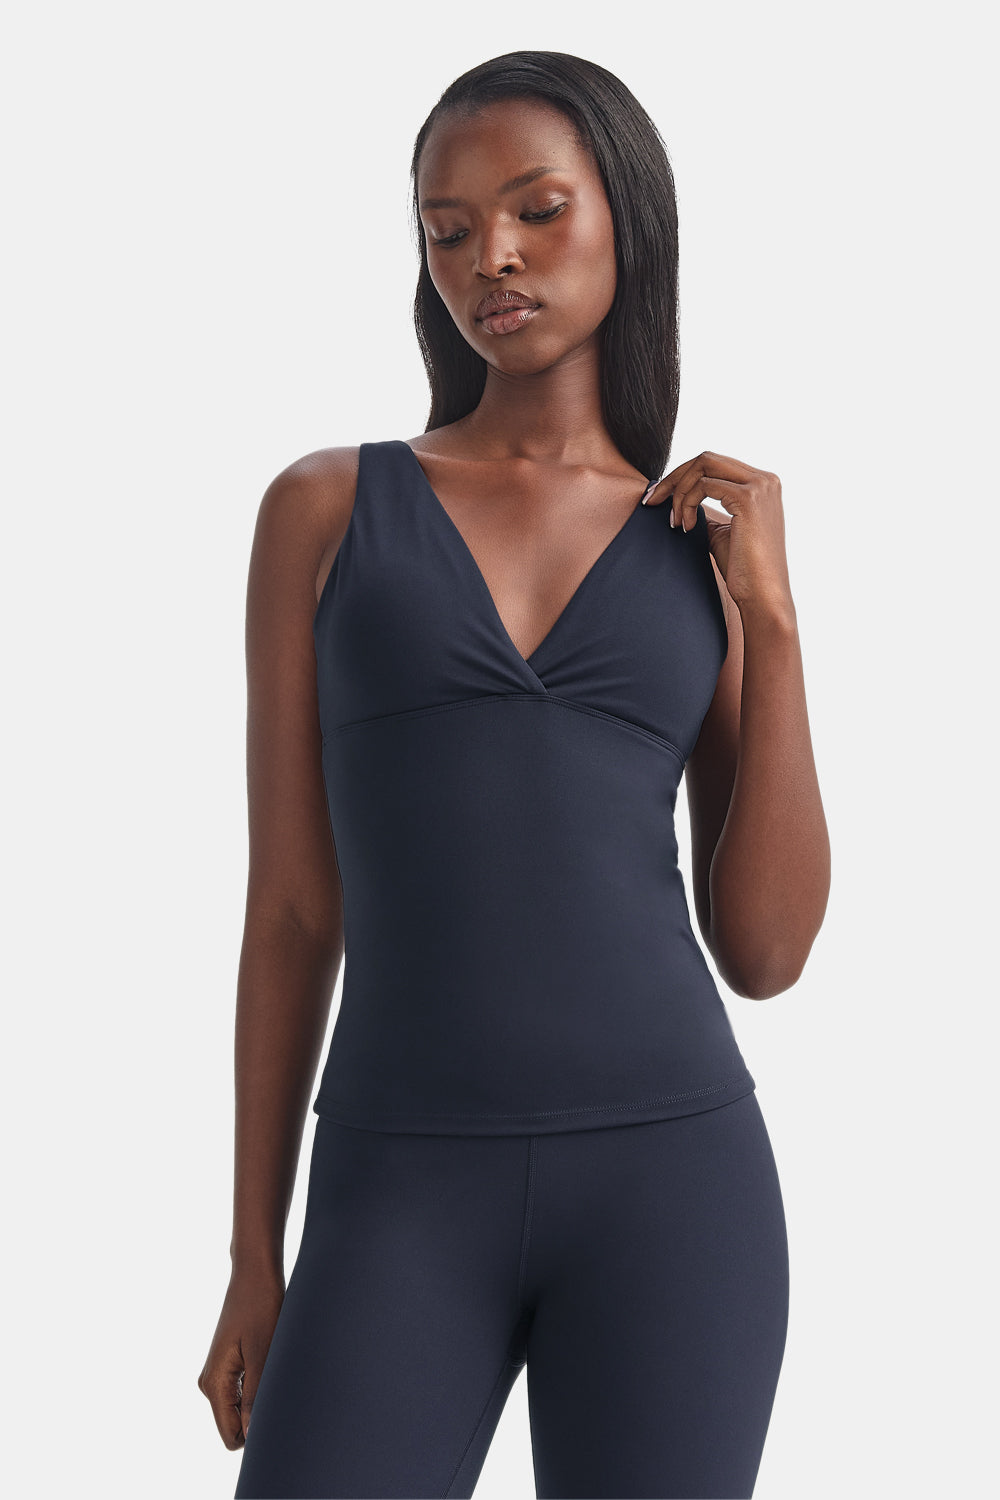

In [3]:
sample_row = image_assets[image_assets["processing_status"] == "downloaded"].iloc[0]
sample_path = PROJECT_ROOT / sample_row["local_path"]
print(f"Example verified official image: {sample_row['asset_id']} ({sample_row['brand']}) -- {sample_row['product_name']}")
if sample_path.exists():
    ipy_display(IPyImage(filename=str(sample_path), width=220))

## 2. Video Package — leads vs. genuinely processed assets

**Binding rule:** a row counts as a processed video asset only if `rights_or_access_basis` permits
local processing AND `processing_status == 'processed'` AND a matching `video_level_features.csv`
row exists with `n_sampled_frames >= 2`. Everything else — including all 61
`platform_metadata_only` YouTube/TikTok rows here — is a **video lead**, reported separately and
never counted toward coverage.

In [4]:
video_coverage = pd.read_csv(TABLES / "video_asset_coverage.csv")
display(video_coverage)

n_leads = int((video_assets["rights_or_access_basis"] == "platform_metadata_only").sum())
n_processed = int((video_assets["processing_status"] == "processed").sum())
print(f"\nVideo leads (metadata only, NOT processed): {n_leads}")
print(f"Genuinely processed video assets: {n_processed}")
print(f"Genuinely downloaded (any status): {int((video_assets['local_path'].notna() & (video_assets['local_path']!='')).sum())}")

,brand,video_leads_metadata_only,candidate_direct_assets_discovered,genuinely_downloaded_pending_or_processed,genuinely_processed_videos,processing_failed
0,Adanola,16,0,0,0,0
1,Girlfriend Collective,13,0,0,0,0
2,Oner Active,8,0,0,0,0
3,TALA,24,1,1,1,0
4,TOTAL,61,1,1,1,0



Video leads (metadata only, NOT processed): 61
Genuinely processed video assets: 1
Genuinely downloaded (any status): 1


In [5]:
video_role_dist = pd.read_csv(TABLES / "video_role_distribution.csv")
display(video_role_dist)

,asset_class,video_role,brand,n_rows
0,genuinely_processed,product_demonstration,TALA,1
1,video_lead_metadata_only,other,TALA,24
2,video_lead_metadata_only,other,Adanola,16
3,video_lead_metadata_only,other,Girlfriend Collective,13
4,video_lead_metadata_only,other,Oner Active,8


### 2a. Shortfall vs. target — reported honestly

Target: 12–20 processable video assets across ≥3 brands, ≥4 TALA, ≥2 distinct video roles.
**Actual: 1 processed video asset, 1 brand (TALA), 1 role (`product_demonstration`).**

Route 1 (official product-page embedded video) found a direct `<source src=.mp4>` only on TALA's
storefront theme — Adanola, Girlfriend Collective, and Oner Active product pages (25 scanned each)
had none. Route 2 (open-licensed video) found none. Route 3 (brand-authorised local video files
under `data/raw/authorised_video_assets/`) has 0 files supplied. No yt-dlp, unofficial downloader,
or stream extraction was used against YouTube/TikTok/Instagram to close this gap — per the charter,
that would be a prohibited access method, not a legitimate remediation.

**This is a genuine, documented shortfall.** The Video Package is marked PARTIAL in
`outputs/tables/assignment_modality_audit.csv`, not silently reported as met.

## 3. Genuine temporal video processing — frame-level and video-level features

In [6]:
display(video_level)
print(f"\nSampled frames for {video_level['video_asset_id'].iloc[0]}: {int(video_level['n_sampled_frames'].iloc[0])}")
print(f"Duration: {video_level['duration_seconds'].iloc[0]:.1f}s, fps: {video_level['fps'].iloc[0]:.1f}")
print(f"has_audio_stream: {video_level['has_audio_stream'].iloc[0]} (None = unknown -- no system ffprobe binary in this environment, a documented limitation, not a fabricated False)")

,video_asset_id,duration_seconds,width,height,fps,frame_count,has_audio_stream,aspect_ratio,n_sampled_frames,mean_frame_embedding_file_hash,...,edge_density_variance,max_semantic_similarity,embedding_std,mean_inter_frame_perceptual_distance,clip_embedding_change_mean,scene_change_count_proxy,motion_intensity_proxy,visual_consistency_score,pct_frames_product_similar,opening_to_closing_visual_change
0,tala_video_001,44.723307,400,720,29.760769,1331,NaN,0.5556,9,98910b7523fe5ad00ddfc79cadda567383680bbf2e37e665ad796709f4689391,...,0.0006,0.2961,0.4872,0.416,0.2127,7,0.2427,0.584,0.8889,0.5781



Sampled frames for tala_video_001: 9
Duration: 44.7s, fps: 29.8
has_audio_stream: nan (None = unknown -- no system ffprobe binary in this environment, a documented limitation, not a fabricated False)


In [7]:
display(video_frames[["frame_id", "sample_position", "timestamp_seconds", "brightness", "contrast",
                        "saturation", "dominant_color_group", "edge_density", "clip_embedding_available",
                        "product_semantic_similarity"]])

,frame_id,sample_position,timestamp_seconds,brightness,contrast,saturation,dominant_color_group,edge_density,clip_embedding_available,product_semantic_similarity
0,tala_video_001_opening,opening,0.000,122.83,47.23,111.25,blue,0.0387,True,0.2729
1,tala_video_001_interval,interval,10.000,123.98,61.20,61.68,greyscale,0.0882,True,0.2961
2,tala_video_001_quarter,quarter,11.156,113.84,60.47,69.96,blue,0.0794,True,0.2815
3,tala_video_001_interval,interval,20.000,115.45,63.11,57.75,orange,0.0388,True,0.2195
4,tala_video_001_half,half,22.345,120.43,43.46,93.61,orange,0.0366,True,0.2257
5,tala_video_001_interval,interval,30.000,109.60,53.67,91.21,orange,0.0378,True,0.2235
6,tala_video_001_three_quarter,three_quarter,33.534,109.89,43.70,101.04,orange,0.0362,True,0.2423
7,tala_video_001_interval,interval,40.000,103.10,41.84,76.33,orange,0.0733,True,0.2595
8,tala_video_001_closing,closing,44.690,164.51,56.08,25.52,greyscale,0.0049,True,0.2599


### 3a. Genuine temporal features (not proxy/thumbnail-only)

These require ≥2 distinct sampled frames and are computed across the frame sequence — a single
thumbnail could never produce them.

In [8]:
temporal_cols = ["video_asset_id", "n_sampled_frames", "mean_inter_frame_perceptual_distance",
                  "clip_embedding_change_mean", "scene_change_count_proxy", "motion_intensity_proxy",
                  "visual_consistency_score", "opening_to_closing_visual_change", "pct_frames_product_similar"]
display(video_level[temporal_cols])
video_feature_summary = pd.read_csv(TABLES / "video_feature_summary.csv")
display(video_feature_summary)

,video_asset_id,n_sampled_frames,mean_inter_frame_perceptual_distance,clip_embedding_change_mean,scene_change_count_proxy,motion_intensity_proxy,visual_consistency_score,opening_to_closing_visual_change,pct_frames_product_similar
0,tala_video_001,9,0.416,0.2127,7,0.2427,0.584,0.5781,0.8889


,n_processed_videos,n_videos_with_ge2_frames,total_sampled_frames,mean_frames_per_video,n_with_temporal_features,n_with_transcript,transcript_coverage_pct,mean_duration_seconds,note
0,1,1,9,9.0,1,0,0.0,44.72,NaN


## 4. Claim-level multimodal evidence candidates

Links each verified official TALA claim to candidate text/image/video/reference evidence
(`scripts/build_claim_multimodal_candidates.py`). This is a **candidate layer**, not a scored
divergence assessment — every row requires human validation before use downstream.

In [9]:
n_claims = len(claim_candidates)
n_text = int((claim_candidates["text_evidence_ids"].fillna("") != "").sum())
n_image = int((claim_candidates["image_asset_ids"].fillna("") != "").sum())
n_video = int((claim_candidates["video_asset_ids"].fillna("") != "").sum())
n_reference = int((claim_candidates["reference_document_ids"].fillna("") != "").sum())
n_all3 = int(((claim_candidates["text_evidence_ids"].fillna("") != "")
              & (claim_candidates["image_asset_ids"].fillna("") != "")
              & (claim_candidates["video_asset_ids"].fillna("") != "")).sum())

print(f"Claims represented: {n_claims}")
print(f"  with text evidence:      {n_text}/{n_claims}")
print(f"  with image evidence:     {n_image}/{n_claims}")
print(f"  with video evidence:     {n_video}/{n_claims}")
print(f"  with reference evidence: {n_reference}/{n_claims}")
print(f"  with text+image+video:   {n_all3}/{n_claims}")
print(f"  requires_human_validation: {int(claim_candidates['requires_human_validation'].sum())}/{n_claims}")

Claims represented: 37
  with text evidence:      21/37
  with image evidence:     3/37
  with video evidence:     0/37
  with reference evidence: 0/37
  with text+image+video:   0/37
  requires_human_validation: 37/37


In [10]:
display(claim_candidates[["claim_id", "claim_category", "claim_text", "text_evidence_ids",
                           "image_asset_ids", "video_asset_ids", "evidence_strength_summary",
                           "missing_modalities"]].head(10))

,claim_id,claim_category,claim_text,text_evidence_ids,image_asset_ids,video_asset_ids,evidence_strength_summary,missing_modalities
0,c_OC_0002_00,labour,"A grassroots UK based social enterprise, The Washing Machine Project's mission is to reduce the ...",NaN,NaN,NaN,unusable,text;image;video;reference
1,c_OC_0002_01,labour,"From talks and demonstrations at HQ to in-store takeovers to spread the word even more, we’re pr...",NaN,NaN,NaN,unusable,text;image;video;reference
2,c_OC_0003_01,materials,We responsibly source and ethically produce our collections using recycled and low-impact materi...,ce_press_0016;cs_0021;ce_rev_0002,tala_005,NaN,medium,video;reference
3,c_OC_0004_00,materials,"With innovative fabrics, sweat-wicking technology and carefully considered fits, our activewear ...",ce_press_0012;ce_press_0014;ce_press_0005,tala_004,NaN,medium,video;reference
4,c_OC_0005_00,labour,"A grassroots UK based social enterprise, The Washing Machine Project's mission is to reduce the ...",NaN,NaN,NaN,unusable,text;image;video;reference
5,c_OC_0005_01,labour,"From talks and demonstrations at HQ to in-store takeovers to spread the word even more, we’re pr...",NaN,NaN,NaN,unusable,text;image;video;reference
6,c_OC_0007_00,labour,"A grassroots UK based social enterprise, The Washing Machine Project's mission is to reduce the ...",NaN,NaN,NaN,unusable,text;image;video;reference
7,c_OC_0007_01,labour,"From talks and demonstrations at HQ to in-store takeovers to spread the word even more, we’re pr...",NaN,NaN,NaN,unusable,text;image;video;reference
8,c_OC_0008_00,labour,"A grassroots UK based social enterprise, The Washing Machine Project's mission is to reduce the ...",NaN,NaN,NaN,unusable,text;image;video;reference
9,c_OC_0008_01,labour,"From talks and demonstrations at HQ to in-store takeovers to spread the word even more, we’re pr...",NaN,NaN,NaN,unusable,text;image;video;reference


**Note on image/video matching:** candidate image/video links are gated to claims in the
`materials` category — a catalog product photo can plausibly corroborate a materials claim, but
nothing in a garment photo can corroborate a labour, manufacturing-process, packaging, emissions,
or circularity claim. No image/video match is fabricated for those categories regardless of CLIP
similarity score. Video matching additionally draws from a pool of exactly one genuinely processed
video, so a 0/37 video-match result reflects real evidence scarcity, not a broken matcher.

## 5. Modality-gap findings — assignment modality audit

In [11]:
display(modality_audit)

,component,required_asset_type,available_assets,verified_assets,directly_processed_assets,proxy_only_assets,missing_assets,status,remediation_action
0,Text Package,official claims + customer experience + creator strategy documents,193,193,193,0,reference documents largely unhydrated for non-TALA brands (see Multimodal Reference Package),PASS,none -- corpora populated and validated in Day 2
1,Image Package,"official catalog/product images, permitted UGC, creator thumbnails",24,24,24,0,0 rows failed verification (missing width/height/hash/URLs),PASS,none required -- >=4 verified official images per brand across 4 brands
2,Video Package,"genuine temporal video assets (sampled frames, motion/scene-change features, transcripts)",62,1,1,61,61 platform_metadata_only video leads (YouTube/TikTok URLs -- correctly excluded from coverage);...,PARTIAL,PARTIAL/FAIL -- place brand-authorised local video files under data/raw/authorised_video_assets/...
3,Multimodal Reference Package,"impact/responsibility reports, certifications, material specs, sizing/care guidance, return poli...",0,0,0,0,package not yet populated -- data/raw/templates/multimodal_reference_assets_template.csv exists ...,FAIL,"collect reference documents (impact reports, certifications, material specs, care/sizing guidanc..."
4,Text Pipeline,TF-IDF/sentiment/embedding features on official/customer/creator text,193,193,193,0,none,PASS,"none -- see data/processed/{official_claim,customer_text}_features.csv"
5,Image Pipeline,interpretable + CLIP embedding features on genuine image assets,24,24,24,0,none,PASS,none
6,Video Pipeline,"genuine temporal features (frame sequence, motion/scene-change, transcript) -- cannot pass on pr...",1,1,1,61,0 processed video(s) without a valid temporal-feature row,PARTIAL,"see Video Package remediation -- Video Pipeline cannot PASS without more genuinely processed, mu..."
7,Claim-evidence candidate layer,claim-linked text/image/video/reference evidence candidates,37,37,0,0,37/37 claims missing >=1 modality (reference evidence missing for all claims -- package not popu...,PARTIAL,populate Multimodal Reference Package and expand Video Package to raise multi-modality coverage;...


## 6. Descriptive engagement — retained, never a modelling target

Engagement prediction is out of scope for the entire project (`CLAUDE.md` §9). The metrics below
are retained strictly for descriptive, non-causal comparison (medians, IQRs, coverage) — see
Notebook 02 §9c for the full modelling-feasibility reclassification (tracks 4–10 marked
`OUT_OF_SCOPE`).

In [12]:
descriptive_engagement = pd.read_csv(TABLES / "descriptive_creator_engagement.csv")
display(descriptive_engagement)

,brand,n_posts,n_with_engagement_count,coverage_pct,median_engagement_count,iqr_low_engagement_count,iqr_high_engagement_count,median_view_count,analysis_type,modelling_target
0,Adanola,16,15,93.75,83.0,48.50,338.00,6250.0,descriptive_only_non_causal,NONE -- engagement prediction is out of scope for this project (CLAUDE.md §9)
1,Girlfriend Collective,13,13,100.00,159.0,102.00,403.00,7086.0,descriptive_only_non_causal,NONE -- engagement prediction is out of scope for this project (CLAUDE.md §9)
2,Oner Active,8,8,100.00,192.5,89.75,343.75,5744.5,descriptive_only_non_causal,NONE -- engagement prediction is out of scope for this project (CLAUDE.md §9)
3,TALA,24,24,100.00,79.0,45.75,140.25,3315.0,descriptive_only_non_causal,NONE -- engagement prediction is out of scope for this project (CLAUDE.md §9)


## 7. Transition to primary claim-evidence fusion and RAG

**Video Package: PARTIAL.** **Multimodal Reference Package: FAIL.** **Claim-evidence candidate
layer: PARTIAL** (0/37 claims have all three of text+image+video evidence; reference evidence is
missing for all 37 claims because the Reference Package is not yet populated).

### GO / NO-GO

| Downstream stage | Verdict |
|---|---|
| Primary claim-evidence fusion | **NO-GO** — Video and Reference packages are not yet adequate for a representative fusion input. |
| Multimodal RAG | **NO-GO** — full multimodal RAG (text + image + video + reference) is premature until Video and Reference packages close their gaps. |

**Remediation before re-attempting fusion/RAG:**
1. Place brand-authorised local video files under `data/raw/authorised_video_assets/` for
   Adanola, Girlfriend Collective, and Oner Active (no yt-dlp/unofficial downloaders).
2. Collect Multimodal Reference Package documents (impact reports, certifications, material
   specs, sizing/care guidance, return policies) per brand.
3. Re-run `python scripts/run_day2_5_modality_alignment.py --refresh` and re-check
   `outputs/tables/assignment_modality_audit.csv`.

Full narrative: `docs/assignment_alignment_audit.md`.

In [13]:
print("=" * 60)
print("NOTEBOOK 03 COMPLETE -- Day 2.5 Video Pipeline and Multimodal Evidence")
print("=" * 60)
print(f"  Verified official images:        {int((image_assets['processing_status']=='downloaded').sum())}")
print(f"  Video leads (not processed):     {n_leads}")
print(f"  Genuinely processed videos:      {n_processed}")
print(f"  Claim bundles:                   {n_claims}")
print(f"  Claims with all 3 modalities:    {n_all3}/{n_claims}")
print(f"  Primary fusion:                  NO-GO (see §7)")
print(f"  Multimodal RAG:                  NO-GO (see §7)")

NOTEBOOK 03 COMPLETE -- Day 2.5 Video Pipeline and Multimodal Evidence
  Verified official images:        24
  Video leads (not processed):     61
  Genuinely processed videos:      1
  Claim bundles:                   37
  Claims with all 3 modalities:    0/37
  Primary fusion:                  NO-GO (see §7)
  Multimodal RAG:                  NO-GO (see §7)
